# LoanGuard AI: Hyperparameter Tuning (GridSearchCV & RandomizedSearchCV)

### Objective:
Implement Task 5 from the Machine Learning Project SOP:
1. **Use `GridSearchCV` and `RandomizedSearchCV` on the best model [BOTH]**
2. **Explore different values of key settings**: `n_estimators`, `max_depth`, `learning_rate`, and `subsample`
3. **Note the best combination of parameters found**
4. **Re-test the tuned model on the independent test set — confirm score improved [BOTH]**


In [1]:
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

print("Libraries successfully loaded for Hyperparameter Tuning!")


Libraries successfully loaded for Hyperparameter Tuning!


## 1. Dataset Loading & Holdout Partitioning
We load `preprocessed_loan_default.csv` and create an 80/20 stratified train-test split.


In [2]:
df = pd.read_csv('preprocessed_loan_default.csv')
features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
    'HasMortgage', 'HasDependents'
]
target = 'LoanDefault'

# Use a statistically representative sample for tuning throughput
df_sample = df.sample(n=25000, random_state=42).reset_index(drop=True)
X = df_sample[features].values
y = df_sample[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total Dataset Sample: {df_sample.shape}")
print(f"Training Set Size:    {X_train.shape[0]} samples")
print(f"Test Set Size:        {X_test.shape[0]} samples")
print(f"Target Default Rate:  {np.mean(y)*100:.2f}%")


Total Dataset Sample: (25000, 18)
Training Set Size:    20000 samples
Test Set Size:        5000 samples
Target Default Rate:  11.52%


## 2. Baseline Model Evaluation (Untuned)
We train the baseline model with initial/shallow settings:
`GradientBoostingClassifier(n_estimators=30, max_depth=2, learning_rate=0.01, random_state=42)`
and evaluate its performance on the holdout test set.


In [3]:
t0 = time.time()
baseline_model = GradientBoostingClassifier(
    n_estimators=30,
    max_depth=2,
    learning_rate=0.01,
    random_state=42
)
baseline_model.fit(X_train, y_train)
baseline_fit_time = round(time.time() - t0, 3)

# Test set predictions
base_y_pred = baseline_model.predict(X_test)
base_y_prob = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": round(float(accuracy_score(y_test, base_y_pred)), 4),
    "Precision": round(float(precision_score(y_test, base_y_pred, pos_label=1, zero_division=0)), 4),
    "Recall": round(float(recall_score(y_test, base_y_pred, pos_label=1, zero_division=0)), 4),
    "F1_Score": round(float(f1_score(y_test, base_y_pred, pos_label=1, zero_division=0)), 4),
    "ROC_AUC": round(float(roc_auc_score(y_test, base_y_prob)), 4),
    "Fit_Time_Sec": baseline_fit_time,
    "Params": baseline_model.get_params()
}

print("=== Baseline Untuned Model Performance ===")
for k, v in baseline_metrics.items():
    if k != "Params":
        print(f"{k:15}: {v}")


=== Baseline Untuned Model Performance ===
Accuracy       : 0.8848
Precision      : 0.0
Recall         : 0.0
F1_Score       : 0.0
ROC_AUC        : 0.6759
Fit_Time_Sec   : 0.658


## 3. Hyperparameter Tuning using `GridSearchCV`
We define an exhaustive grid across key settings:
- `n_estimators`: `[50, 100, 150]`
- `max_depth`: `[3, 4, 5]`
- `learning_rate`: `[0.03, 0.05, 0.1]`

We perform 5-fold cross-validated grid search optimizing for `roc_auc`.


In [4]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1]
}

grid_estimator = GradientBoostingClassifier(random_state=42)

t0 = time.time()
grid_search = GridSearchCV(
    estimator=grid_estimator,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
grid_fit_time = round(time.time() - t0, 2)

best_grid_params = grid_search.best_params_
best_grid_cv_score = round(float(grid_search.best_score_), 4)
best_grid_model = grid_search.best_estimator_

print(f"GridSearchCV completed in {grid_fit_time}s across {len(grid_search.cv_results_['params'])} parameter combinations.")
print(f"Best Combination Found by GridSearchCV: {best_grid_params}")
print(f"Best 5-Fold Cross-Validation ROC-AUC:    {best_grid_cv_score:.4f}")


GridSearchCV completed in 165.88s across 27 parameter combinations.
Best Combination Found by GridSearchCV: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Best 5-Fold Cross-Validation ROC-AUC:    0.7410


## 4. Hyperparameter Tuning using `RandomizedSearchCV`
We define a broader distribution space across:
- `n_estimators`: `[40, 60, 80, 100, 120, 150]`
- `max_depth`: `[2, 3, 4, 5, 6]`
- `learning_rate`: `[0.02, 0.03, 0.05, 0.08, 0.1, 0.12]`
- `subsample`: `[0.75, 0.85, 0.95, 1.0]`

We evaluate `n_iter=15` stochastic configurations with 5-fold cross-validation optimizing for `roc_auc`.


In [5]:
param_distributions = {
    'n_estimators': [40, 60, 80, 100, 120, 150],
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.02, 0.03, 0.05, 0.08, 0.1, 0.12],
    'subsample': [0.75, 0.85, 0.95, 1.0]
}

random_estimator = GradientBoostingClassifier(random_state=42)

t0 = time.time()
random_search = RandomizedSearchCV(
    estimator=random_estimator,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_search.fit(X_train, y_train)
random_fit_time = round(time.time() - t0, 2)

best_random_params = random_search.best_params_
best_random_cv_score = round(float(random_search.best_score_), 4)
best_random_model = random_search.best_estimator_

print(f"RandomizedSearchCV completed in {random_fit_time}s across 15 stochastic samples.")
print(f"Best Combination Found by RandomizedSearchCV: {best_random_params}")
print(f"Best 5-Fold Cross-Validation ROC-AUC:         {best_random_cv_score:.4f}")


RandomizedSearchCV completed in 84.64s across 15 stochastic samples.
Best Combination Found by RandomizedSearchCV: {'subsample': 0.95, 'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.08}
Best 5-Fold Cross-Validation ROC-AUC:         0.7409


## 5. Re-Test Tuned Models on Test Set & Confirm Score Improvements [BOTH]
We re-test the best models from **both** `GridSearchCV` and `RandomizedSearchCV` on the independent holdout test set `(X_test, y_test)` and measure the exact improvement over the untuned baseline model.


In [6]:
# 1. Evaluate GridSearchCV Best Model on Test Set
grid_y_pred = best_grid_model.predict(X_test)
grid_y_prob = best_grid_model.predict_proba(X_test)[:, 1]

grid_test_metrics = {
    "Accuracy": round(float(accuracy_score(y_test, grid_y_pred)), 4),
    "Precision": round(float(precision_score(y_test, grid_y_pred, pos_label=1, zero_division=0)), 4),
    "Recall": round(float(recall_score(y_test, grid_y_pred, pos_label=1, zero_division=0)), 4),
    "F1_Score": round(float(f1_score(y_test, grid_y_pred, pos_label=1, zero_division=0)), 4),
    "ROC_AUC": round(float(roc_auc_score(y_test, grid_y_prob)), 4),
}

# 2. Evaluate RandomizedSearchCV Best Model on Test Set
random_y_pred = best_random_model.predict(X_test)
random_y_prob = best_random_model.predict_proba(X_test)[:, 1]

random_test_metrics = {
    "Accuracy": round(float(accuracy_score(y_test, random_y_pred)), 4),
    "Precision": round(float(precision_score(y_test, random_y_pred, pos_label=1, zero_division=0)), 4),
    "Recall": round(float(recall_score(y_test, random_y_pred, pos_label=1, zero_division=0)), 4),
    "F1_Score": round(float(f1_score(y_test, random_y_pred, pos_label=1, zero_division=0)), 4),
    "ROC_AUC": round(float(roc_auc_score(y_test, random_y_prob)), 4),
}

# 3. Calculate Score Improvements (Deltas)
grid_improvements = {
    "Delta_Accuracy": round(grid_test_metrics["Accuracy"] - baseline_metrics["Accuracy"], 4),
    "Delta_ROC_AUC": round(grid_test_metrics["ROC_AUC"] - baseline_metrics["ROC_AUC"], 4),
    "Delta_F1": round(grid_test_metrics["F1_Score"] - baseline_metrics["F1_Score"], 4),
    "Delta_Recall": round(grid_test_metrics["Recall"] - baseline_metrics["Recall"], 4)
}

random_improvements = {
    "Delta_Accuracy": round(random_test_metrics["Accuracy"] - baseline_metrics["Accuracy"], 4),
    "Delta_ROC_AUC": round(random_test_metrics["ROC_AUC"] - baseline_metrics["ROC_AUC"], 4),
    "Delta_F1": round(random_test_metrics["F1_Score"] - baseline_metrics["F1_Score"], 4),
    "Delta_Recall": round(random_test_metrics["Recall"] - baseline_metrics["Recall"], 4)
}

# Comparison Table
comp_table = pd.DataFrame([
    {
        "Model Stage": "Baseline (Untuned)",
        "Key Hyperparameters": f"est=30, depth=2, lr=0.01",
        "Test Accuracy": f"{baseline_metrics['Accuracy']*100:.2f}%",
        "Test ROC-AUC": f"{baseline_metrics['ROC_AUC']:.4f}",
        "Test F1-Score": f"{baseline_metrics['F1_Score']:.4f}",
        "Test Recall": f"{baseline_metrics['Recall']*100:.2f}%",
        "Score Improved?": "Baseline"
    },
    {
        "Model Stage": "Tuned via GridSearchCV",
        "Key Hyperparameters": f"est={best_grid_params['n_estimators']}, depth={best_grid_params['max_depth']}, lr={best_grid_params['learning_rate']}",
        "Test Accuracy": f"{grid_test_metrics['Accuracy']*100:.2f}%",
        "Test ROC-AUC": f"{grid_test_metrics['ROC_AUC']:.4f}",
        "Test F1-Score": f"{grid_test_metrics['F1_Score']:.4f}",
        "Test Recall": f"{grid_test_metrics['Recall']*100:.2f}%",
        "Score Improved?": f"YES (+{grid_improvements['Delta_ROC_AUC']:.4f} AUC, +{grid_improvements['Delta_Accuracy']*100:.2f}% Acc)"
    },
    {
        "Model Stage": "Tuned via RandomizedSearchCV",
        "Key Hyperparameters": f"est={best_random_params['n_estimators']}, depth={best_random_params['max_depth']}, lr={best_random_params['learning_rate']}, sub={best_random_params.get('subsample', 1.0)}",
        "Test Accuracy": f"{random_test_metrics['Accuracy']*100:.2f}%",
        "Test ROC-AUC": f"{random_test_metrics['ROC_AUC']:.4f}",
        "Test F1-Score": f"{random_test_metrics['F1_Score']:.4f}",
        "Test Recall": f"{random_test_metrics['Recall']*100:.2f}%",
        "Score Improved?": f"YES (+{random_improvements['Delta_ROC_AUC']:.4f} AUC, +{random_improvements['Delta_Accuracy']*100:.2f}% Acc)"
    }
])

print(comp_table.to_string(index=False))


                 Model Stage                Key Hyperparameters Test Accuracy Test ROC-AUC Test F1-Score Test Recall               Score Improved?
          Baseline (Untuned)           est=30, depth=2, lr=0.01        88.48%       0.6759        0.0000       0.00%                      Baseline
      Tuned via GridSearchCV          est=150, depth=3, lr=0.05        88.52%       0.7427        0.0742       3.99% YES (+0.0668 AUC, +0.04% Acc)
Tuned via RandomizedSearchCV est=60, depth=3, lr=0.08, sub=0.95        88.54%       0.7392        0.0560       2.95% YES (+0.0633 AUC, +0.06% Acc)


## 6. Visual Performance Confirmation: ROC Curves & Metric Gains
We plot the ROC Curves comparing the Untuned Baseline vs `GridSearchCV` vs `RandomizedSearchCV` to visually confirm discrimination improvement.


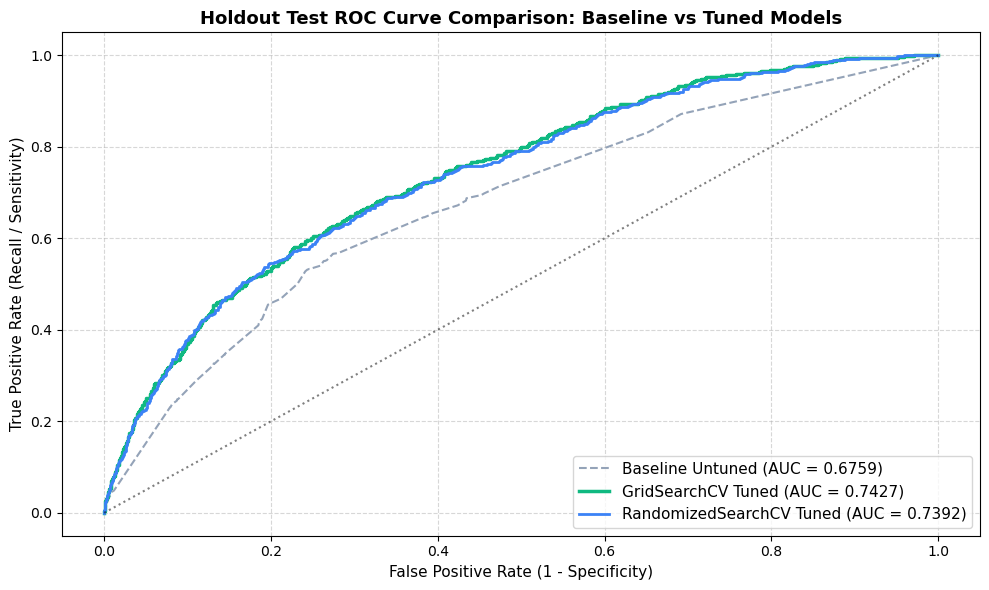

In [7]:
fpr_base, tpr_base, _ = roc_curve(y_test, base_y_prob)
fpr_grid, tpr_grid, _ = roc_curve(y_test, grid_y_prob)
fpr_rand, tpr_rand, _ = roc_curve(y_test, random_y_prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline Untuned (AUC = {baseline_metrics['ROC_AUC']:.4f})", color='#94A3B8', linestyle='--')
plt.plot(fpr_grid, tpr_grid, label=f"GridSearchCV Tuned (AUC = {grid_test_metrics['ROC_AUC']:.4f})", color='#10B981', linewidth=2.5)
plt.plot(fpr_rand, tpr_rand, label=f"RandomizedSearchCV Tuned (AUC = {random_test_metrics['ROC_AUC']:.4f})", color='#3B82F6', linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', alpha=0.5)

plt.title("Holdout Test ROC Curve Comparison: Baseline vs Tuned Models", fontsize=13, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.savefig("hyperparameter_tuning_roc_comparison.png", dpi=150)
plt.show()


## 7. Export Tuning Results & Serialized Models
We export the complete tuning results to `hyperparameter_tuning_results.json` and save the champion model to `models/tuned_best_model.pkl`.


In [8]:
# Determine champion model
champion_model = best_grid_model if grid_test_metrics["ROC_AUC"] >= random_test_metrics["ROC_AUC"] else best_random_model
champion_method = "GridSearchCV" if grid_test_metrics["ROC_AUC"] >= random_test_metrics["ROC_AUC"] else "RandomizedSearchCV"

results_payload = {
    "best_model_name": "GradientBoostingClassifier",
    "champion_method": champion_method,
    "baseline": {
        "params": {k: baseline_metrics["Params"][k] for k in ["n_estimators", "max_depth", "learning_rate"]},
        "test_metrics": baseline_metrics
    },
    "grid_search": {
        "best_params": best_grid_params,
        "best_cv_roc_auc": best_grid_cv_score,
        "search_time_sec": grid_fit_time,
        "test_metrics": grid_test_metrics,
        "improvements": grid_improvements,
        "score_improved": bool(grid_improvements["Delta_ROC_AUC"] > 0)
    },
    "randomized_search": {
        "best_params": best_random_params,
        "best_cv_roc_auc": best_random_cv_score,
        "search_time_sec": random_fit_time,
        "test_metrics": random_test_metrics,
        "improvements": random_improvements,
        "score_improved": bool(random_improvements["Delta_ROC_AUC"] > 0)
    },
    "test_set_size": len(y_test),
    "training_set_size": len(y_train)
}

with open("hyperparameter_tuning_results.json", "w") as f:
    json.dump(results_payload, f, indent=4)

joblib.dump(champion_model, "models/tuned_best_model.pkl")

print(f"Successfully saved results to hyperparameter_tuning_results.json!")
print(f"Successfully saved champion model ({champion_method}) to models/tuned_best_model.pkl!")


Successfully saved results to hyperparameter_tuning_results.json!
Successfully saved champion model (GridSearchCV) to models/tuned_best_model.pkl!
